In [ ]:
import torch
import torch.optim as optim
from torchviz import make_dot
import pandas as pd
from itables import init_notebook_mode, show
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import importlib
from tqdm import tqdm
from torchvision import transforms

import gradual_aacbr
import semantics.mlp_semantics as ms
import semantics.relu_semantics as rs
import base_scores.feature_weighted_base_score as fwbs
import casebase_edge_weights.feature_weighted_partial_order as fwpo
import casebase_edge_weights.learned_partial_order as lpo
import irrelevance_edge_weights.feature_weighted_irrelevance as fwi
import irrelevance_edge_weights.regular_irrelevance as ri

init_notebook_mode(all_interactive=True)

In [ ]:
def reload_imports():
    importlib.reload(gradual_aacbr)
    importlib.reload(ms)
    importlib.reload(rs)
    importlib.reload(fwbs)
    importlib.reload(fwpo)
    importlib.reload(fwi)
    importlib.reload(ri)
    importlib.reload(lpo)

reload_imports()

## Gradual AACBR

In [ ]:
"""
                    1: (3, 0)
                       ^
                       |
3: (5, 0) <------> 2: (5, 1)
                   /   |
                  /    v
                 /  0: (1, 0)
                /      |
              |_       v
5: (default, 0)  4: (default, 1)

"""


reload_imports()
X_train = torch.tensor([
    [1], # (0, 0)
    [3], # (1, 0)
    [5], # (2, 1)
    [5], # (3, 0)
], dtype=torch.float32)

y_train = torch.tensor([
    [1, 0], 
    [1, 0], 
    [0, 1], 
    [1, 0]
], dtype=torch.float32)

X_default = torch.tensor([
        [0], [0]
], dtype=torch.float32) # 4, 5
y_default = torch.tensor([[0, 1], [1, 0]], dtype=torch.float32)

torch.manual_seed(1)

no_features = X_train.shape[-1]
# semantics = ms.MLPBasedSemantics(max_iters=5, epsilon=0)
semantics = rs.ReluSemantics(max_iters=5, epsilon=0)

edge_weights_test = lambda a, t: torch.where(torch.all(a >= t, axis=1), 1.0, 0.0) 


model = gradual_aacbr.GradualAACBR(semantics, 
                                   fwbs.FeatureWeightedBaseScore(no_features), 
                                   fwi.FeatureWeightedIrrelevance(no_features), 
                                   edge_weights_test
                                   )

model.fit(X_train, y_train, X_default, y_default, use_symmetric_attacks=True)
# model.fit_no_blockers(X_train, y_train, X_default, y_default)
# model.plot_casebase_edge_weights_parameters()

new_case = torch.tensor([
    [2],
], dtype=torch.float32)

strengths = model(new_case)
print(strengths)

model.show_matrix()
model.show_graph_with_labels()



## Data Set

In [ ]:
SEED = 42

In [ ]:
# MNIST
# from torchvision.datasets import MNIST
# mnist_trainset = MNIST("./temp/", train=True, download=True)
# mnist_testset = MNIST("./temp/", train=False, download=True)


# X = mnist_trainset.data[:1000].view(-1, 784).float()
# y = mnist_trainset.targets[:1000]
# print(X.shape)
# print(np.unique(y))

In [ ]:
# # data = pd.read_csv('data/connectionist-bench-sonar-mines-vs-rocks/sonar.all-data')
data = pd.read_csv('data/iris/iris.data')

data = data.values

X = np.array(data[:, :-1], dtype=np.float32)
y = np.array(data[:, -1])

show(X)
print(np.unique(y))




In [ ]:
y = y.reshape(-1, 1)
encoder = OneHotEncoder(sparse_output=False)
# encoder = LabelEncoder()
encoder.fit(y)
y = encoder.transform(y)

show(y)
all_y = np.unique(y, axis=0)

## Train Model

### Split into Training, Validation and Test

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=SEED)
print(f"Test Size:  {len(X_test)}")
print(f"Train Size:  {len(X_train)}")
print(f"Validation Size:  {len(X_val)}")

### Cluster dataset

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

GROUP_PROPORTION = 0.25 
# GROUP_PROPORTION = 0.5

# Example data
# X = np.random.randn(132, 2)


# cluster_size_func = lambda total_size: 15

cluster_size_func = lambda total_size: int(total_size * GROUP_PROPORTION)


X_all_centroids = []
y_all_centroids = []

for selected_y in all_y:


    group = X_train[np.all(selected_y == y_train, axis=1)]

    # Number of clusters
    k = cluster_size_func(len(group))

    print(f"{k} clusters for {selected_y}")

    # Create a KMeans object
    kmeans = KMeans(n_clusters=k, random_state=0)

    # Fit the model to the data and predict cluster assignments
    cluster_assignments = kmeans.fit_predict(group)

    # Get the centroids
    X_centroids_group = kmeans.cluster_centers_
    y_centroids_group = np.tile(selected_y, (k, 1))

    X_all_centroids.append(X_centroids_group)
    y_all_centroids.append(y_centroids_group)

X_centroids =  np.concatenate(X_all_centroids)
y_centroids =  np.concatenate(y_all_centroids)

In [ ]:
# X_train = X_centroids
# y_train = y_centroids
X_centroids = torch.tensor(X_centroids, dtype=torch.float32)
y_centroids = torch.tensor(y_centroids, dtype=torch.float32)

### Convert to Torch

In [ ]:
X_train_full, y_train_full = torch.tensor(X_train_full), torch.tensor(y_train_full, dtype=torch.float32)
X_train, y_train = torch.tensor(X_train), torch.tensor(y_train, dtype=torch.float32)
X_val, y_val = torch.tensor(X_val), torch.tensor(y_val, dtype=torch.float32)
X_test, y_test = torch.tensor(X_test), torch.tensor(y_test, dtype=torch.float32)

### Normalize dataset

In [ ]:
train_mean = X_train.mean(dim=0)
train_std = X_train.std(dim=0)

X_train = (X_train - train_mean)/train_std
X_centroids = (X_centroids - train_mean)/train_std
X_val = (X_val - train_mean)/train_std
X_test = (X_test - train_mean)/train_std



In [ ]:
print(X_train)

### Build AF

In [ ]:

# Compare against the average for each column
means = X_train.mean(axis=0)
std = X_train.std(axis=0)

print(means)
print(std)

In [ ]:
PREPROCESS_FUNC = lambda x: x

### Train Model

In [ ]:
DEFAULT_CASE = means
# DEFAULT_CASE = torch.zeros_like(means)

X_DEFAULTS = PREPROCESS_FUNC(DEFAULT_CASE.tile(len(all_y), 1))
Y_DEFAULTS = torch.tensor(all_y)


In [ ]:
PREPROCESS_FUNC(X_centroids)

In [ ]:
MAX_ITERS = 20
EPOCHS = 1500
USE_SYMMETRIC_ATTACKS = False
LR = 0.01
MOMENTUM = 0.9
SHARPNESS = 1
# SHARPNESS = 1

# not technically a hp - want it to work regardless of this
TORCH_SEED = 67



In [ ]:
reload_imports()

def run_gradual_model(model: gradual_aacbr.GradualAACBR, X_train, y_train, 
                      X_default, y_default, new_cases, use_symmetric_attacks = USE_SYMMETRIC_ATTACKS):

    # model.fit(PREPROCESS_FUNC(X_train), y_train, X_default, y_default, USE_SYMMETRIC_ATTACKS)
    # model.fit_no_blockers(PREPROCESS_FUNC(X_train), y_train, X_default, y_default, USE_SYMMETRIC_ATTACKS)

    # model.fit(PREPROCESS_FUNC(X_centroids), y_centroids, X_default, y_default, USE_SYMMETRIC_ATTACKS)
    model.fit_no_blockers(PREPROCESS_FUNC(X_centroids), y_centroids, X_default, y_default, use_symmetric_attacks)
    return model(PREPROCESS_FUNC(new_cases))


def evaluate_model(model, X_train, y_train, X_default, y_default, new_cases, new_cases_labels, print_results = True,
                   show_confusion=False, print_graph=False, print_matrix=False, print_compute_graph = False, 
                   use_symmetric_attacks=USE_SYMMETRIC_ATTACKS):


    final_strengths = run_gradual_model(model, X_train, y_train, X_default, y_default, new_cases, use_symmetric_attacks=use_symmetric_attacks)
    predicted = final_strengths.cpu().detach().numpy()

    predicted = np.argmax(predicted, axis=1)
    new_cases_labels_orig = np.argmax(new_cases_labels, axis=1)


    results = (
        accuracy_score(new_cases_labels_orig, predicted),
        precision_score(new_cases_labels_orig, predicted, average='macro'),
        recall_score(new_cases_labels_orig, predicted, average='macro'),
        f1_score(new_cases_labels_orig, predicted, average='macro')
    )

    if print_results:
        print("Accuracy, Precision, Recall, F1")
        print(results)


    if show_confusion:
        cm = confusion_matrix(new_cases_labels_orig, predicted)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()
        plt.show()

    if print_graph:
        model.show_graph_with_labels()

    if print_matrix:
        model.show_matrix()

    if print_compute_graph:
        criterion = torch.nn.CrossEntropyLoss()
        loss = criterion(final_strengths.squeeze(), new_cases_labels)
        make_dot(loss, params=dict(model.named_parameters())).render("gradual_aacbr", format="pdf")
    
    return results



In [ ]:
reload_imports()
torch.manual_seed(TORCH_SEED) # TRY DIFFERENT INITIAL WEIGHTS 

no_features = X_train.shape[-1]
# semantics = ms.MLPBasedSemantics(max_iters=MAX_ITERS, epsilon=0)
semantics = rs.ReluSemantics(max_iters=MAX_ITERS, epsilon=0)
partial_order = fwpo.FeatureWeightedPartialOrder(no_features, sharpness=SHARPNESS)
# partial_order = lpo.LearnedPartialOrder(no_features, no_hidden=10, sharpness=2)
irrelevance = ri.RegularIrrelevance(partial_order)
# irrelevance = fwi.FeatureWeightedIrrelevance(no_features)
base_score = fwbs.FeatureWeightedBaseScore(no_features)

model = gradual_aacbr.GradualAACBR(semantics, 
                                base_score,
                                irrelevance,
                                partial_order)

# criterion = torch.nn.BCELoss()
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)

In [ ]:
reload_imports()
evaluate_model(model, X_train, y_train, X_DEFAULTS, Y_DEFAULTS, X_val, y_val, show_confusion=True,  print_matrix=True, print_compute_graph=True, print_graph = False )
# show(model.A.detach().numpy())
model.plot_casebase_edge_weights_parameters()
model.plot_base_score_parameters()

In [ ]:

DISABLE_TQDM = False

In [ ]:
reload_imports()

def train(model, optimizer, criterion, epochs=EPOCHS, use_symmetric_attacks = USE_SYMMETRIC_ATTACKS, print_gradients = False, plot_loss_curve = False):
    losses = []
    pbar = tqdm(range(epochs), disable=DISABLE_TQDM)

    for epoch in pbar:  

            new_cases = X_train
            new_cases_labels = y_train


            optimizer.zero_grad()

            # TODO: consider efficiency issues with having to rebuild each time 
            # Find a way to accumulate gradients update only when necessary?
            model.fit_no_blockers(PREPROCESS_FUNC(X_centroids), y_centroids, X_DEFAULTS, Y_DEFAULTS, use_symmetric_attacks)
            # model.fit(PREPROCESS_FUNC(X_centroids), y_centroids, X_DEFAULTS, Y_DEFAULTS, USE_SYMMETRIC_ATTACKS)

            predictions = model(PREPROCESS_FUNC(new_cases)).squeeze()
            loss = criterion(predictions, new_cases_labels)
            loss.backward()

            optimizer.step()
            losses.append(loss.item())


            pbar.set_description(f'Epoch {epoch + 1}, Loss: {round(loss.item()/len(new_cases), 4)}')


    if print_gradients:
        print("Gradients:")
        for name, param in model.named_parameters():
            if param.grad is not None:
                print(f"Function: {name} | Gradients: {param.grad}")
            else:
                print(f"Function: {name} | No gradients computed")

    if plot_loss_curve:

        plt.plot(losses)
        plt.show()

train(model, optimizer, criterion)

In [ ]:
reload_imports()
with torch.no_grad():
    evaluate_model(model, X_train, y_train, X_DEFAULTS, Y_DEFAULTS, X_val, y_val, show_confusion=True,  print_matrix=True, print_compute_graph=False, print_graph=True  )

model.plot_casebase_edge_weights_parameters()
model.plot_base_score_parameters()

In [ ]:
assert(False)

### Hyperparameter Tuning

In [123]:
reload_imports()
import ray
from ray import tune


def objective(config, test_set = False, show_confusion = False, print_matrix = False, 
              print_compute_graph = False, print_graph = False, print_results = False):
    torch.manual_seed(config["seed"]) # TRY DIFFERENT INITIAL WEIGHTS 

    no_features = X_train.shape[-1]
    semantics = rs.ReluSemantics(max_iters=config["no_iters"], epsilon=0)
    partial_order = fwpo.FeatureWeightedPartialOrder(no_features, sharpness=config["sharpness"])
    # partial_order = lpo.LearnedPartialOrder(no_features, no_hidden=10, sharpness=2)
    irrelevance = ri.RegularIrrelevance(partial_order)
    # irrelevance = fwi.FeatureWeightedIrrelevance(no_features)
    base_score = fwbs.FeatureWeightedBaseScore(no_features)

    model = gradual_aacbr.GradualAACBR(semantics, 
                                    base_score,
                                    irrelevance,
                                    partial_order)

    # criterion = torch.nn.BCELoss()
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=config["lr"], momentum=MOMENTUM)

    train(model, optimizer, criterion, epochs=config["epochs"], use_symmetric_attacks=config["symmetric_attacks"])

    if test_set:
        accuracy, precision, recall, f1 = evaluate_model(model, X_train_full, y_train_full, X_DEFAULTS, Y_DEFAULTS, X_test, y_test, 
                                        show_confusion=show_confusion, print_matrix=print_matrix, 
                                        print_compute_graph=print_compute_graph, print_graph=print_graph, 
                                        print_results=print_results, use_symmetric_attacks=config["symmetric_attacks"])
    else:
        accuracy, precision, recall, f1 = evaluate_model(model, X_train, y_train, X_DEFAULTS, Y_DEFAULTS, X_val, y_val, 
                                        show_confusion=show_confusion, print_matrix=print_matrix, 
                                        print_compute_graph=print_compute_graph, print_graph=print_graph, 
                                        print_results=print_results, use_symmetric_attacks=config["symmetric_attacks"])


    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1 }


def tune_model(search_space, num_cpus=12, num_samples=1000, metric="accuracy"):
    if not ray.is_initialized():
        ray.init(num_cpus=num_cpus)

    tuner = tune.Tuner(
        tune.with_parameters(objective, test_set=False),
        tune_config=tune.TuneConfig(
            metric=metric,
            mode="max",
            num_samples=num_samples,
        ),
        param_space=search_space
    )

    results = tuner.fit()
    best_params = results.get_best_result().config
    print("BEST PARAMETERS FOR MODEL ARE:")
    print(best_params)
    print("Best score found was: ", results.get_best_result().metrics[metric])
    return best_params


search_space = {
    "no_iters": tune.choice([15, 20, 25]),
    "epochs": tune.choice([250, 750, 1500, 3000]),
    "lr": tune.loguniform(1e-4, 1e-1),
    "sharpness": tune.loguniform(1e-1, 1e1),
    "seed": tune.randint(0, 100),
    "symmetric_attacks": tune.choice([True, False]),
}


In [124]:
best_results = tune_model(search_space, metric="f1", num_samples=2000)




2024-08-24 20:57:21,862	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/adam/ray_results/objective_2024-08-24_19-44-34' in 0.2527s.
2024-08-24 20:57:22,192	INFO tune.py:1041 -- Total run time: 4367.23 seconds (4366.57 seconds for the tuning loop).


BEST PARAMETERS FOR MODEL ARE:
{'no_iters': 20, 'epochs': 3000, 'lr': 0.027724410326258685, 'sharpness': 0.6052368105626966, 'seed': 36, 'symmetric_attacks': False}
Best score found was:  0.6958473625140291


In [125]:
print(best_results)


{'no_iters': 20, 'epochs': 3000, 'lr': 0.027724410326258685, 'sharpness': 0.6052368105626966, 'seed': 36, 'symmetric_attacks': False}


Epoch 3000, Loss: 0.0084: 100%|██████████| 3000/3000 [00:18<00:00, 158.07it/s]


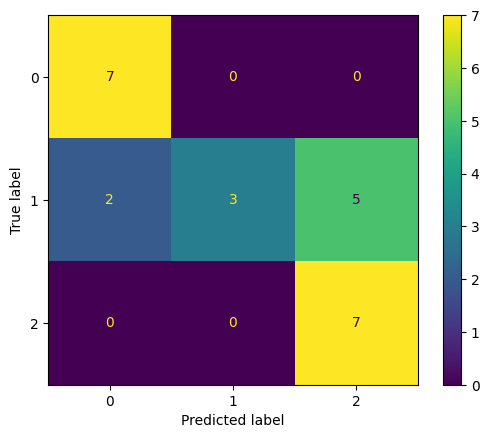

{'accuracy': 0.7083333333333334,
 'precision': 0.7870370370370371,
 'recall': 0.7666666666666666,
 'f1': 0.6911268556005399}

In [128]:

# best_results = {'no_iters': 20, 'epochs': 250, 'lr': 0.01,  'sharpness': 1, 'seed': 66, 'symmetric_attacks': False}
# best_results = {'no_iters': 20, 'epochs': 1500, 'lr': 0.01, 'sharpness': 1, 'seed': 67, 'symmetric_attacks': False}
# best_results = {'no_iters': 20, 'epochs': 1500, 'lr': 0.01,   'sharpness': 1, 'seed': 44, 'symmetric_attacks': False}
# best_results = {'no_iters': 25, 'epochs': 750, 'lr': 0.001378029134146083, 'sharpness': 2.1258661320458896, 'seed': 67, 'symmetric_attacks': True}
best_results = {'no_iters': 20, 'epochs': 3000, 'lr': 0.027724410326258685, 'sharpness': 0.6052368105626966, 'seed': 36, 'symmetric_attacks': False}
objective(best_results, show_confusion=True)


### Test Set

Epoch 3000, Loss: 0.0084: 100%|██████████| 3000/3000 [00:17<00:00, 169.49it/s]


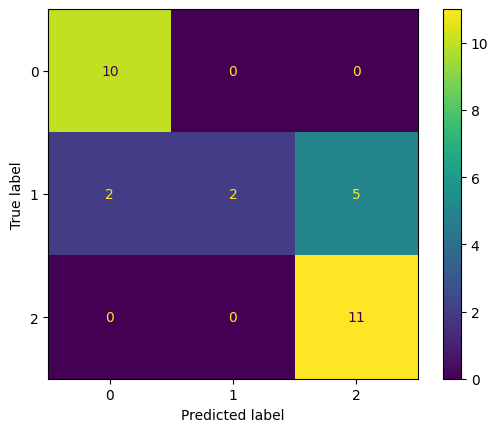

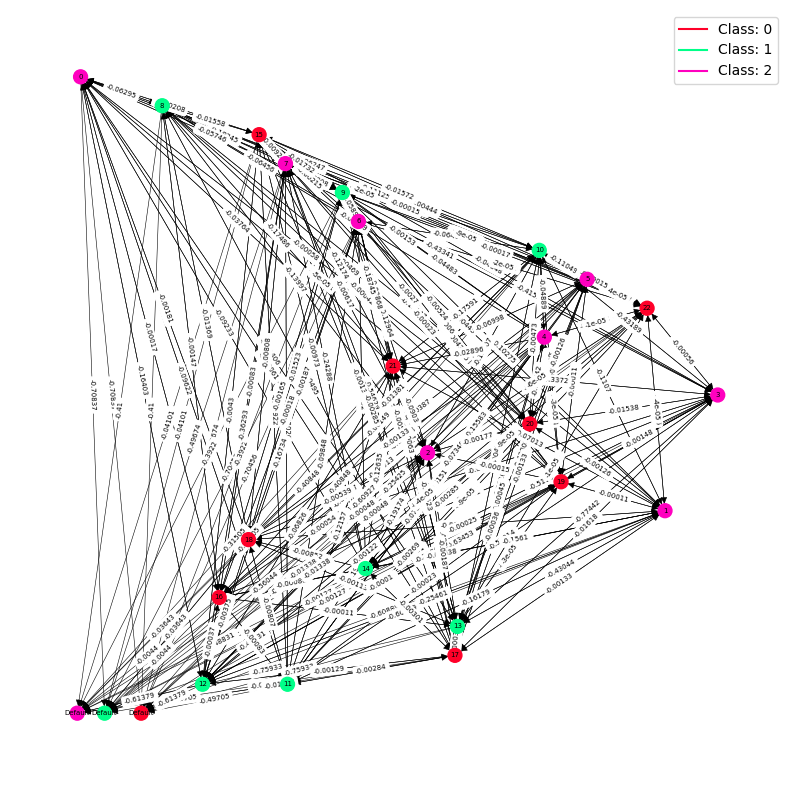

{'accuracy': 0.7666666666666667,
 'precision': 0.8402777777777778,
 'recall': 0.7407407407407408,
 'f1': 0.6958473625140291}

In [129]:
reload_imports()
objective(best_results, test_set=True, show_confusion=True, print_graph=True)

In [ ]:
# reload_imports()
# with torch.no_grad():
#     evaluate_model(model, X_train_full, y_train_full, X_DEFAULTS, Y_DEFAULTS, X_test, y_test, show_confusion=True,  print_matrix=True, print_compute_graph=True, print_graph = False )